In [5]:
from google.colab import files
uploaded = files.upload()
# Pilih file online_shoppers_intention.csv dari komputer Anda

Saving online_shoppers_intention.csv to online_shoppers_intention (1).csv


In [6]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# modeling
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import plot_tree

# evaluasi
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [30]:
# 2.1 Baca dataset
df = pd.read_csv('online_shoppers_intention.csv')

# 2.2 Cek ukuran data
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# 2.3 Info dataset
print("\n📋 Info Dataset:")
df.info()

# 2.4 Cek missing values
print(f"\n📋 Missing Values per kolom:\n{df.isnull().sum()}")

# 2.5 Cek target
print(f"\n📋 Distribusi Target (Revenue):")
print(df['Revenue'].value_counts())
print(f"Persentase: {df['Revenue'].value_counts(normalize=True) * 100}")

Jumlah baris: 12330
Jumlah kolom: 18

📋 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                

In [32]:
# 2.6 Lihat 5 data pertama
print("\n📋 5 Data Pertama:")
df.head()



📋 5 Data Pertama:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [29]:
# 2.7 Statistik deskriptif
print("\n📋 Statistik Deskriptif:")
df.describe()


📋 Statistik Deskriptif:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


**Analisis data Understanding**

* Dataset memiliki 12.330 baris dan 18 kolom. Dari 5 data pertama terlihat bahwa
dataset terdiri dari campuran tipe data numerik (int64, float64), kategorikal (object), dan boolean (bool).
* Tidak ada missing values pada semua kolom (non-null count = 12.330 untuk seluruh kolom), sehingga dataset sudah bersih dan siap diproses tanpa perlu imputasi.
* Statistik deskriptif menunjukkan bahwa rata-rata pengunjung mengakses 2.32 halaman administrative (Administrative) dengan durasi 80.82 detik, dan 31.73 halaman produk (ProductRelated) dengan durasi 1.194,75 detik (~20 menit). Ini mengindikasikan bahwa pengunjung menghabiskan lebih banyak waktu di halaman produk dibandingkan halaman administrative dan informasional. BounceRate rata-rata 0.022 (2.2%) dan ExitRate rata-rata 0.043 (4.3%), sementara PageValues rata-rata 5.89 dengan nilai maksimum 361.76 yang menunjukkan adanya outlier signifikan.

* Distribusi target 'Revenue' menunjukkan ketidakseimbangan yang signifikan: 10.422 sesi (84.5%) tidak menghasilkan pembelian (Revenue=False), sedangkan hanya 1.908 sesi (15.5%) yang menghasilkan pembelian (Revenue=True). Ketidakseimbangan ini menjadi tantangan dalam pemodelan karena model cenderung memprediksi kelas mayoritas. Oleh karena itu, metrik F1-Score dan Recall akan lebih penting daripada Accuracy dalam evaluasi model nanti.

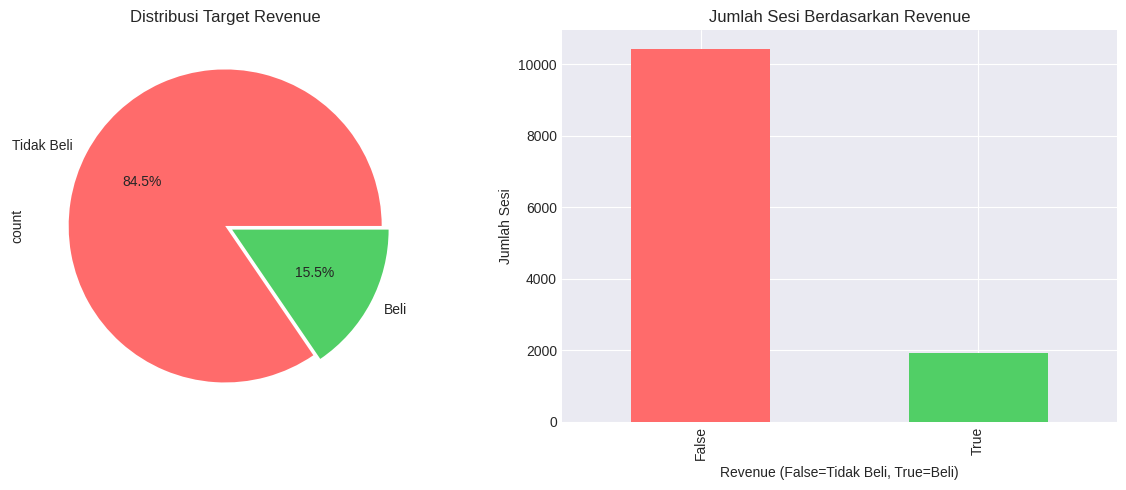

In [8]:
# Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
df['Revenue'].value_counts().plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    explode=[0, 0.05],
    labels=['Tidak Beli', 'Beli'],
    colors=['#ff6b6b', '#51cf66'],
    title='Distribusi Target Revenue'
)

# Bar Chart
df['Revenue'].value_counts().plot.bar(
    ax=axes[1],
    color=['#ff6b6b', '#51cf66'],
    title='Jumlah Sesi Berdasarkan Revenue'
)
axes[1].set_xlabel('Revenue (False=Tidak Beli, True=Beli)')
axes[1].set_ylabel('Jumlah Sesi')

plt.tight_layout()
plt.show()

**Visualisasi Distribusi Target**

Dari pie chart dan bar chart di atas, terlihat bahwa:
- Sebagian besar sesi (84.5%) tidak menghasilkan pembelian (Revenue = False)
- Hanya 15.5% sesi yang menghasilkan pembelian (Revenue = True)
- Selisih jumlah antara kedua kelas sangat signifikan (10.422 vs 1.908)

Interpretasi: Tingginya rasio pengunjung yang tidak membeli menunjukkan bahwa banyak pengunjung yang hanya browsing tanpa melakukan transaksi. Model prediktif perlu difokuskan untuk mengidentifikasi 15.5% pengunjung yang berpotensi membeli agar strategi marketing dapat ditargetkan secara tepat.

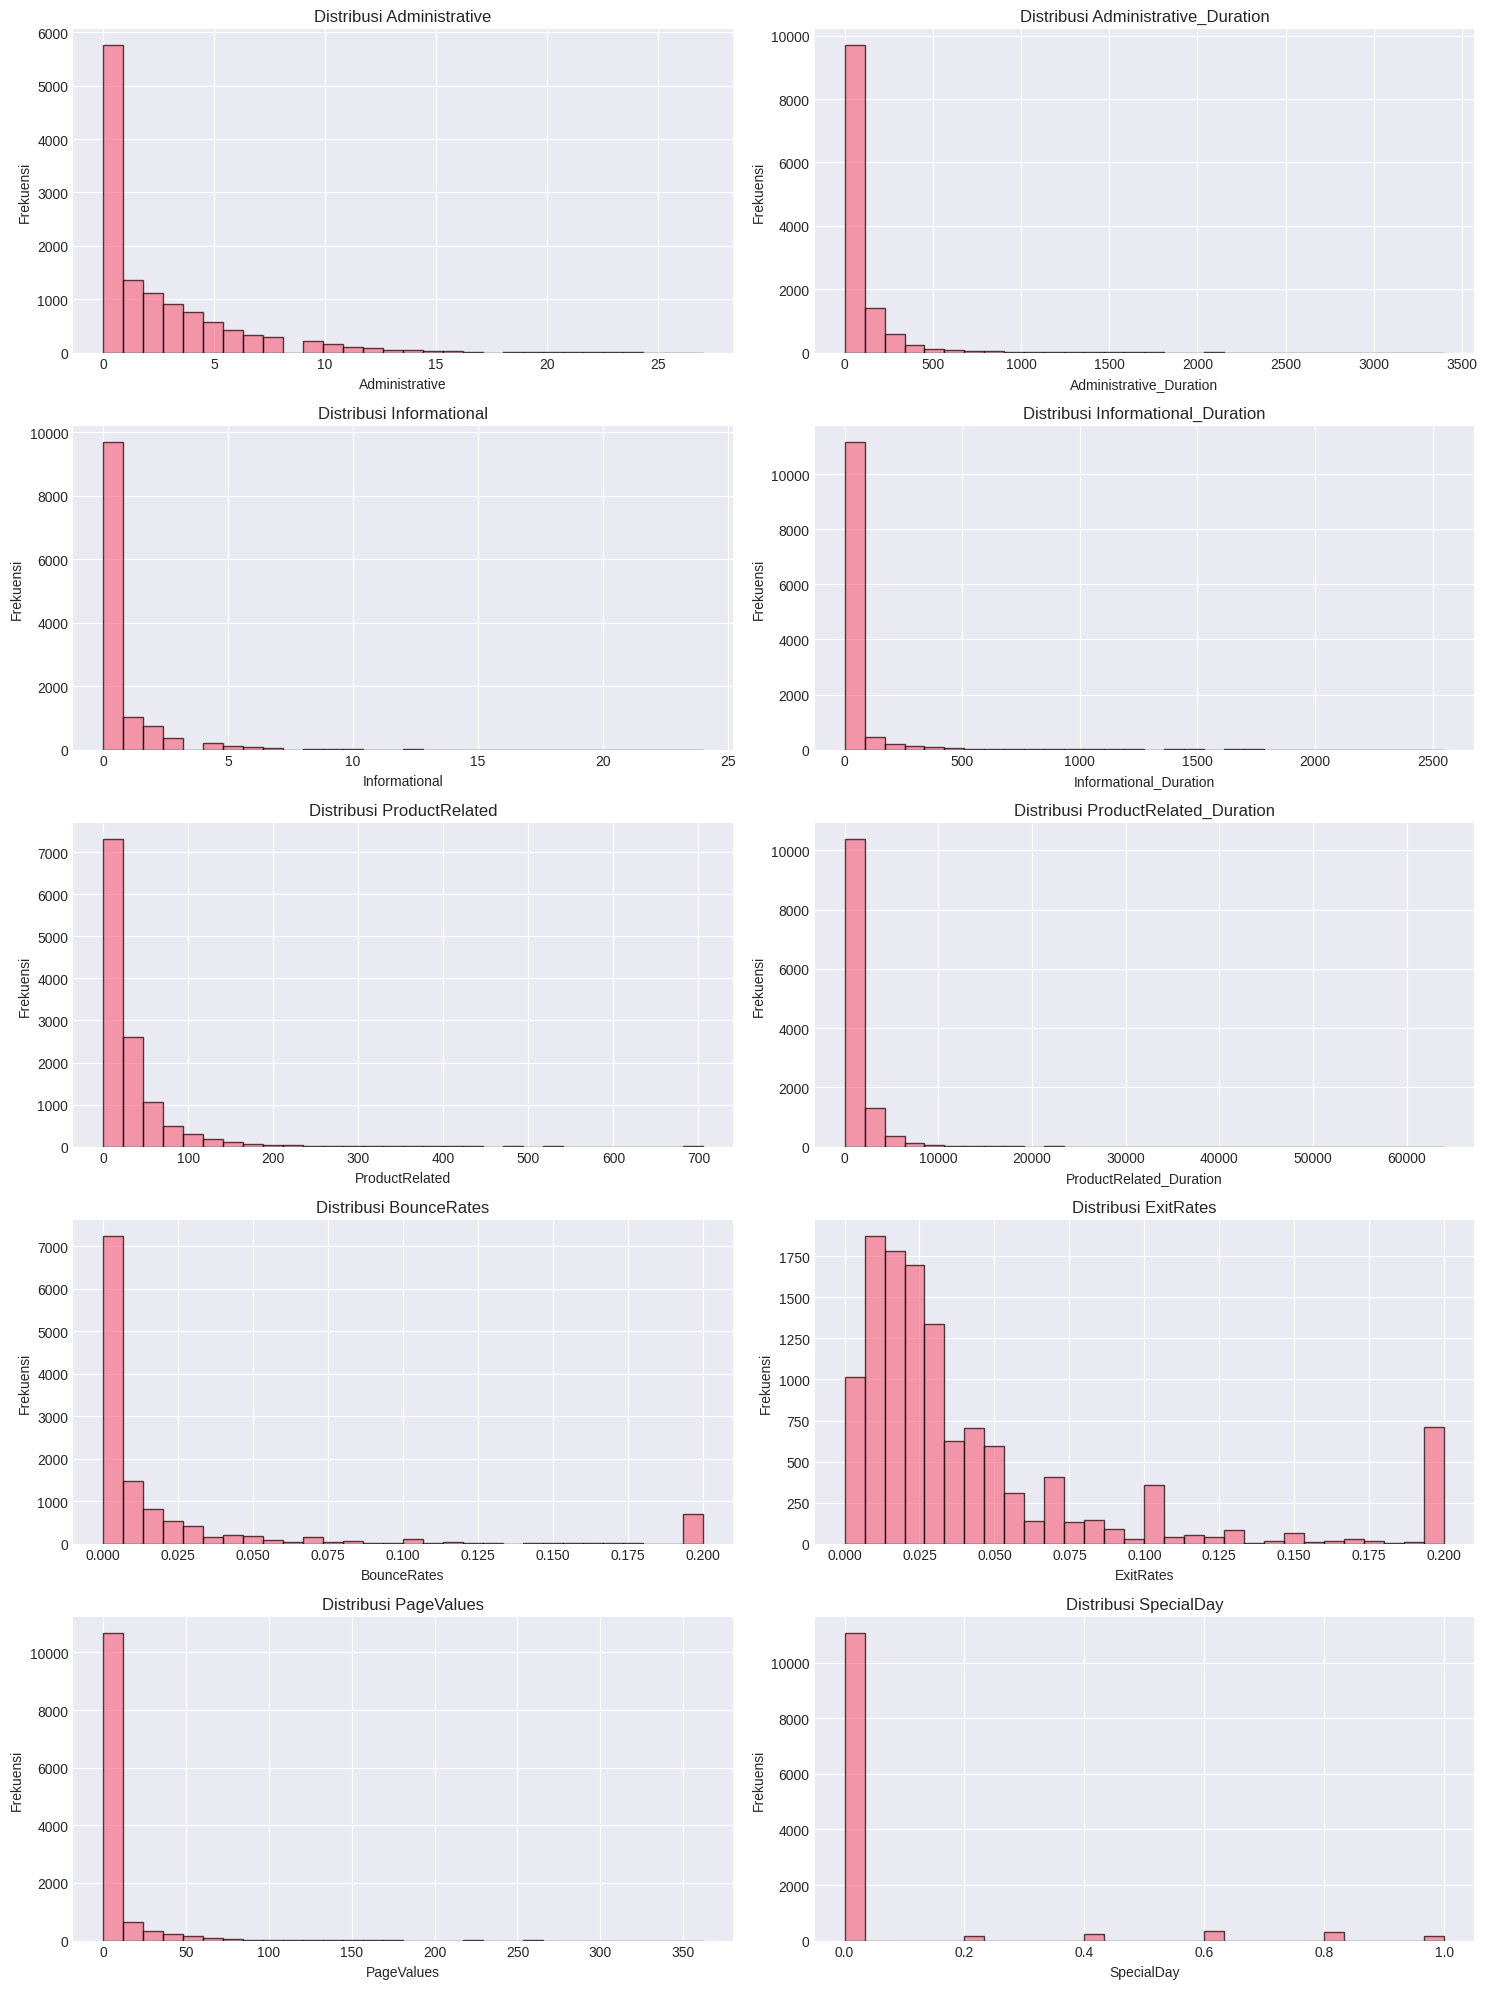

In [9]:
# Pilih fitur numerik
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                  'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                  'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

# Buat histogram
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

 **Analisis Distribusi Fitur Numerik**

Dari histogram 10 fitur numerik, terlihat bahwa:
- **Administrative & Administrative_Duration**: Mayoritas pengunjung mengakses 0-4 halaman admin dengan durasi di bawah 200 detik, terdapat beberapa outlier dengan akses yang sangat tinggi
- **Informational & Informational_Duration**: Distribusi sangat miring ke kanan, kebanyakan pengunjung tidak mengakses halaman informasi (nilai 0)
- **ProductRelated & ProductRelated_Duration**: Distribusi miring ke kanan, mayoritas mengakses 0-50 halaman produk dengan durasi bervariasi hingga 1.000+ detik, menunjukkan minat pengunjung lebih besar pada produk
- **BounceRates & ExitRates**: Sebagian besar berada di rentang 0-0.05 dengan beberapa outlier hingga 0.20
- **PageValues**: Mayoritas bernilai 0 (belum ada transaksi), dengan beberapa outlier hingga >350
- **SpecialDay**: Hampir seluruhnya bernilai 0, hanya sedikit yang mendekati hari spesial (nilai mendekati 1)

**Kesimpulan**: Fitur ProductRelated_Duration dan PageValues memiliki variasi terbesar dan berpotensi menjadi prediktor kuat untuk target Revenue.

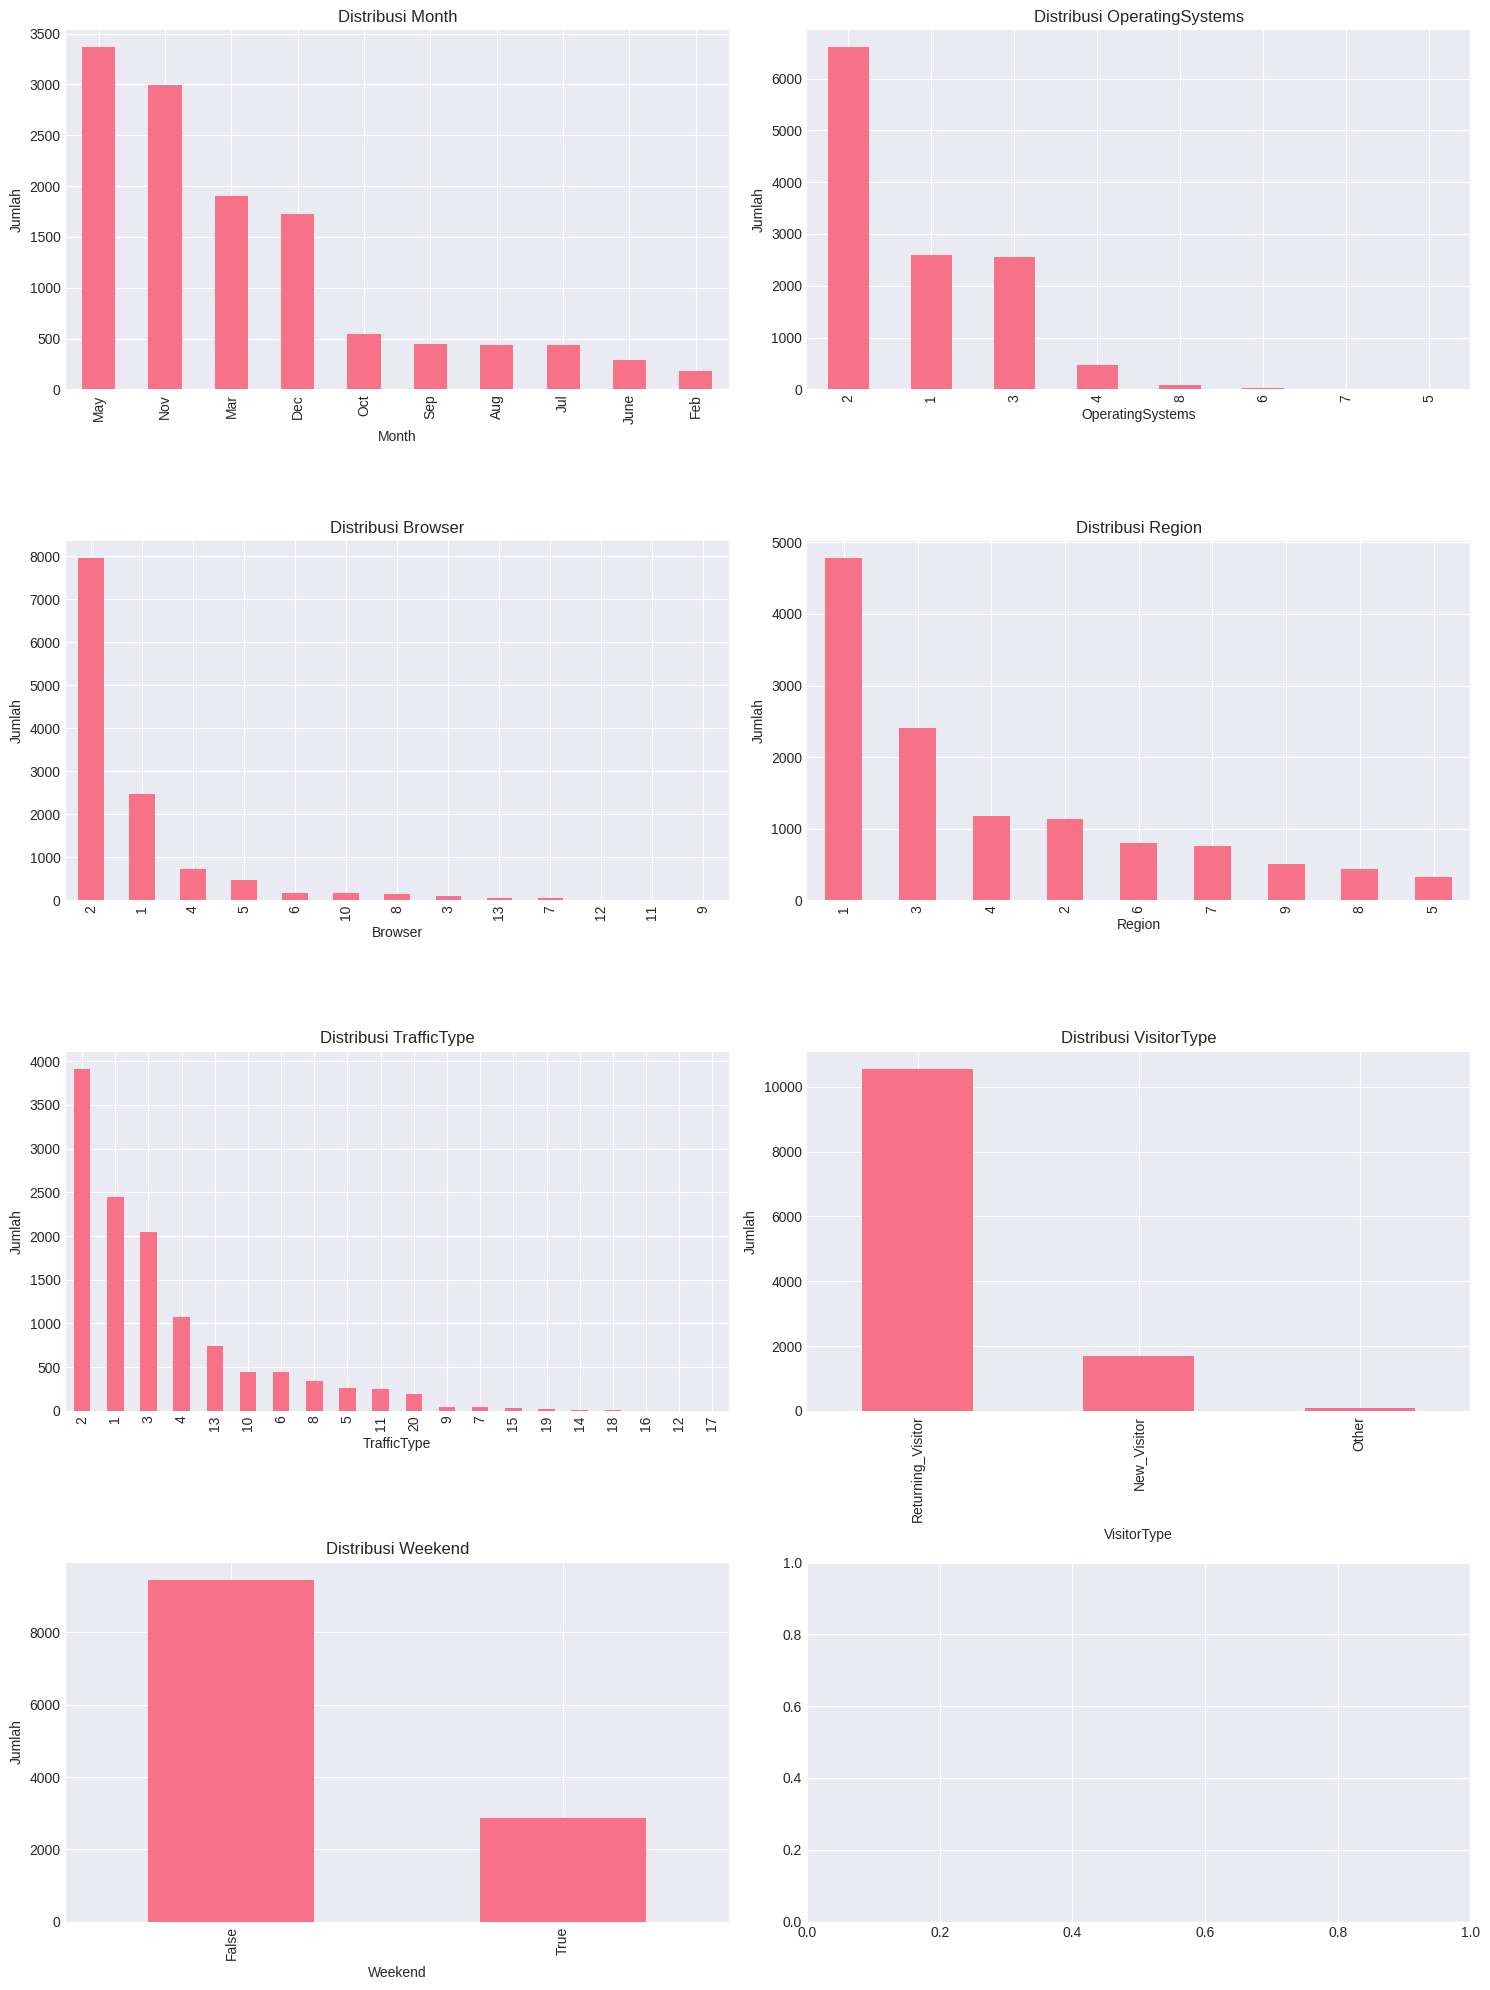

In [33]:
# Fitur kategorikal
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region',
                    'TrafficType', 'VisitorType', 'Weekend']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot.bar(ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

**Analisis Distribusi Fitur Kategorikal**

Dari bar chart 7 fitur kategorikal, diperoleh insight sebagai berikut:

1. **Month (Bulan)**:
   - Bulan Mei (May) memiliki kunjungan terbanyak
   - Bulan November (Nov) memiliki kunjungan paling sedikit
   - Terjadi fluktuasi kunjungan antar bulan yang cukup signifikan

2. **OperatingSystems**:
   - Sistem operasi dengan kode 2 paling dominan
   - Sistem operasi dengan kode 8 paling jarang digunakan

3. **Browser**:
   - Browser dengan kode 2 paling banyak digunakan pengunjung
   - Browser dengan kode 13 paling sedikit

4. **Region**:
   - Region dengan kode 1 dan 3 paling dominan
   - Region dengan kode 8 dan 9 paling sedikit

5. **TrafficType**:
   - Traffic type dengan kode 2 paling dominan
   - Traffic type dengan kode 19 dan 20 sangat jarang

6. **VisitorType**:
   - Didominasi oleh Returning_Visitor (pengunjung kembali)
   - New_Visitor dan Other memiliki porsi yang jauh lebih kecil

7. **Weekend**:
   - Sebagian besar kunjungan terjadi di hari kerja (Weekend = False)
   - Kunjungan di akhir pekan jauh lebih sedikit

**Kesimpulan**: Returning_Visitor mendominasi traffic, kunjungan tertinggi di bulan Mei, dan sebagian besar kunjungan terjadi di hari kerja. Fitur-fitur ini dapat mempengaruhi prediksi pembelian.

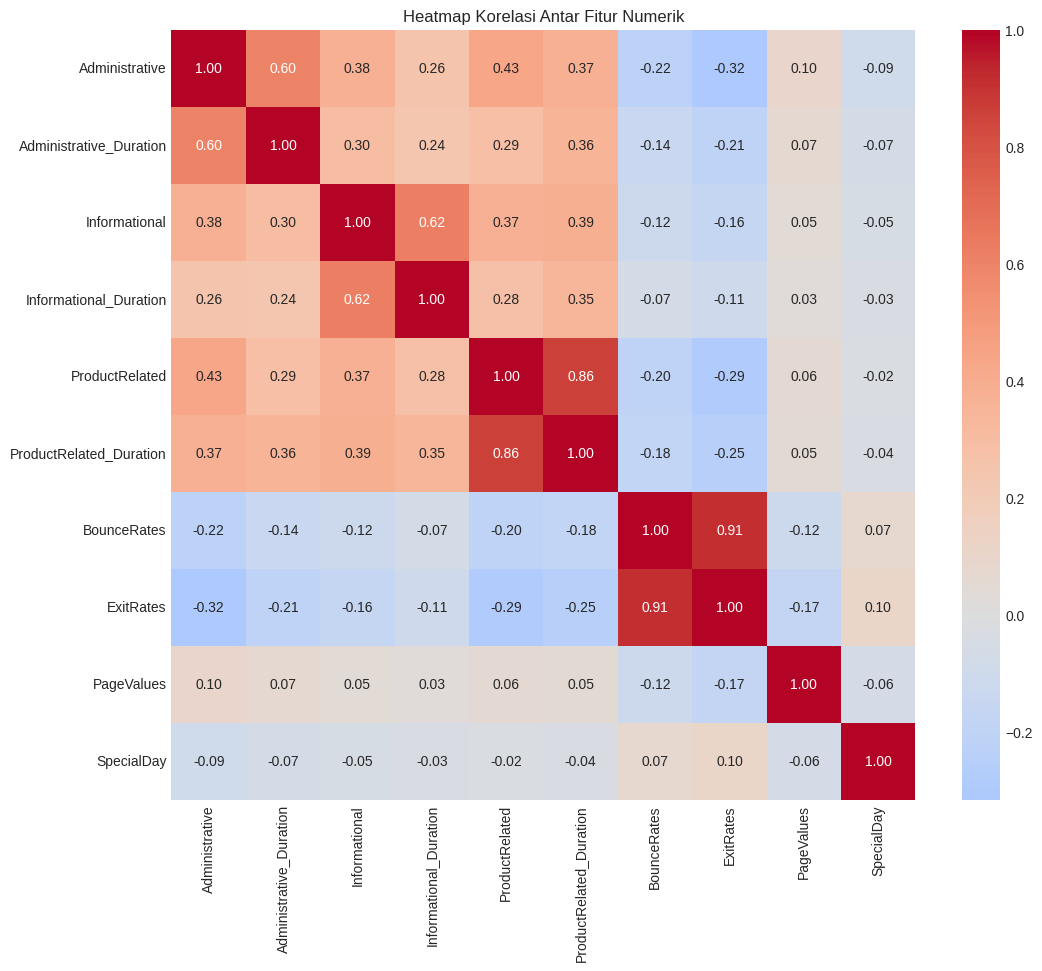

In [11]:
# Korelasi antar fitur numerik
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

**Analisis korelasi antar fitur**

Dari heatmap di atas, ditemukan korelasi tertinggi pada:
- ExitRates dengan BounceRates (0.91): kedua metrik saling terkait erat
- ProductRelated_Duration dengan ProductRelated (0.86): semakin banyak halaman produk, semakin lama durasi
- Administrative_Duration dengan Administrative (0.60): aktivitas admin berkorelasi dengan durasi

Korelasi negatif terlihat antara BounceRates/ExitRates dengan ProductRelated (-0.20 s.d -0.29), menunjukkan pengunjung yang aktif menjelajah produk cenderung tidak langsung meninggalkan situs. PageValues memiliki korelasi rendah dengan semua fitur (0.03-0.10).

**Implikasi**: Fitur ProductRelated dan ProductRelated_Duration memiliki redundansi tinggi (0.86), begitu pula BounceRates dan ExitRates (0.91).


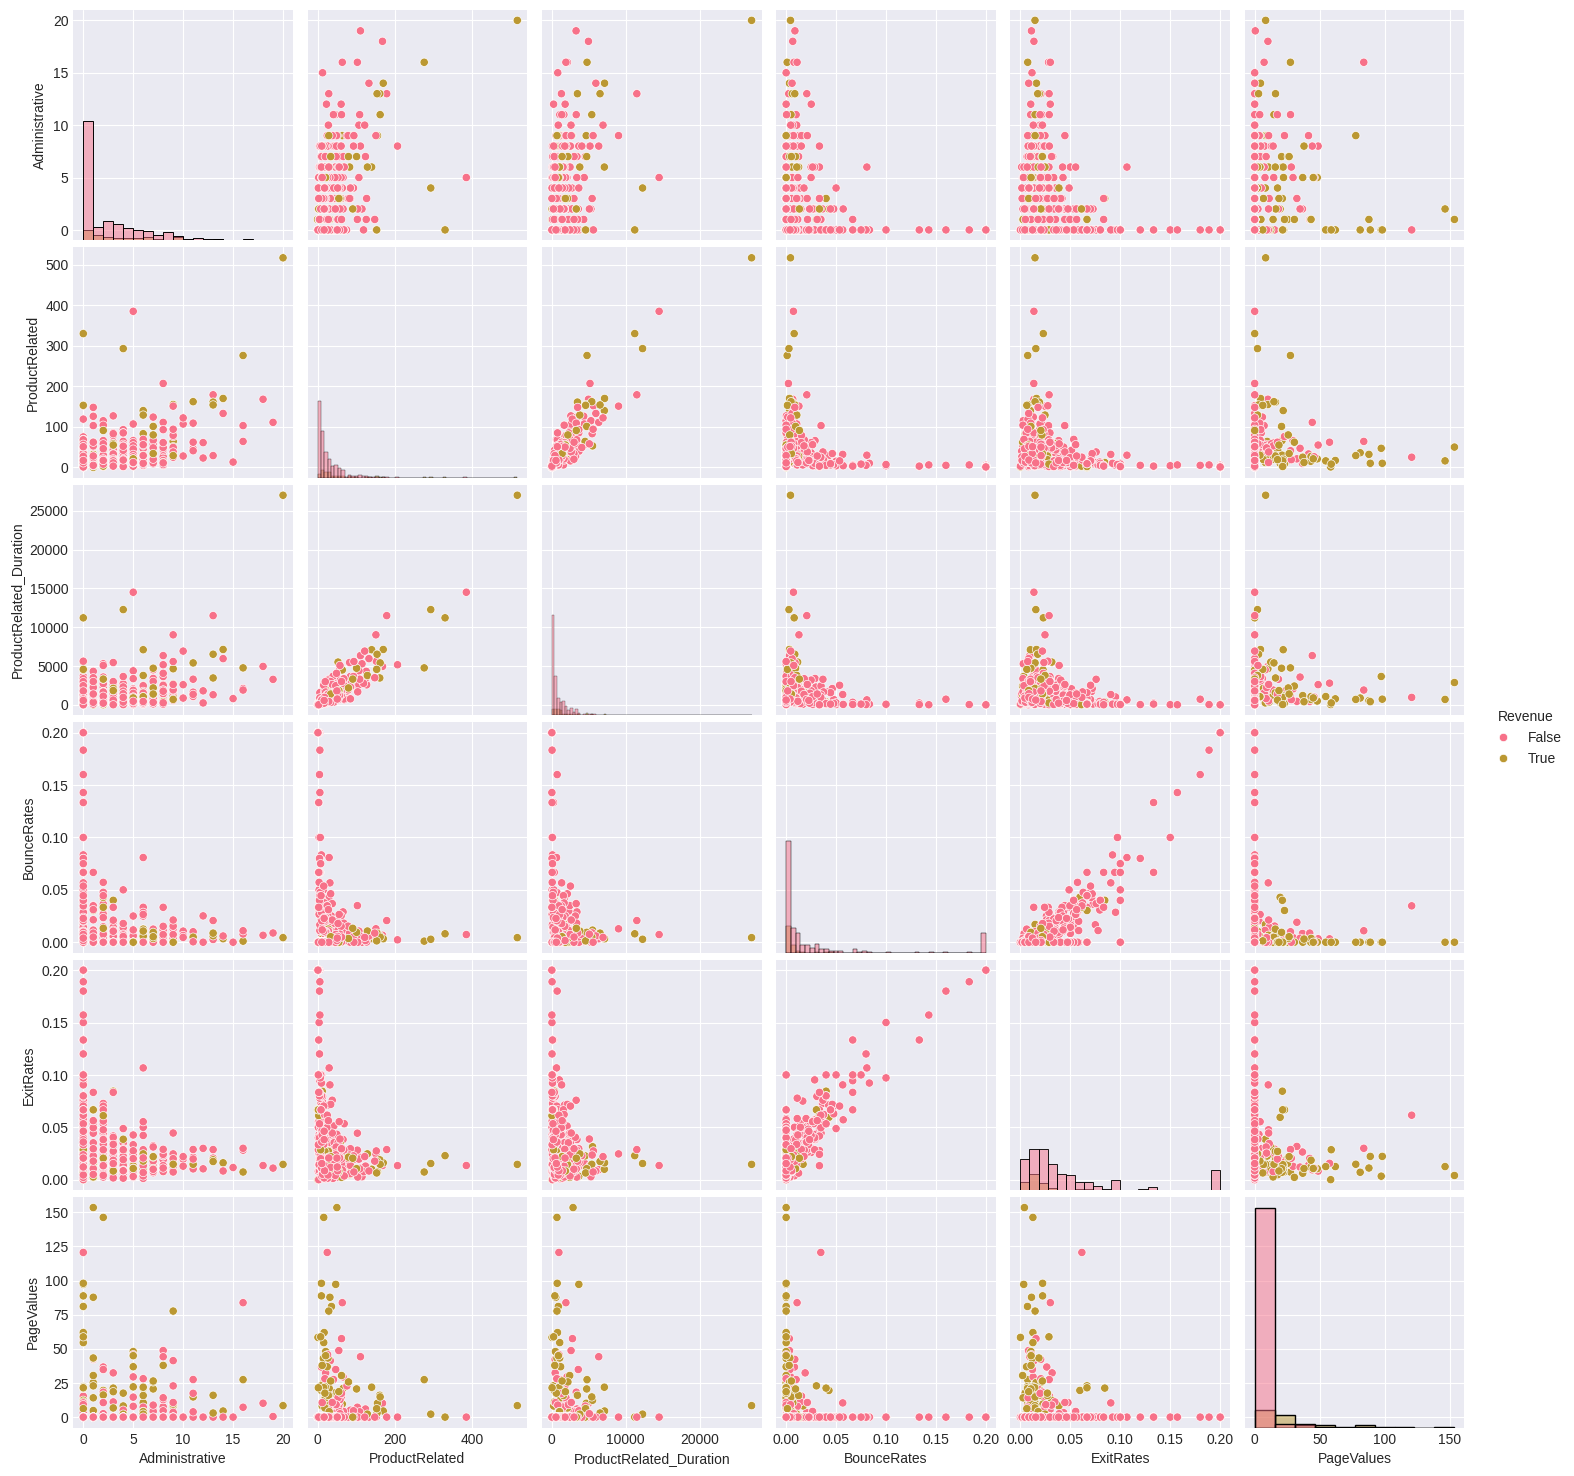

In [12]:
# Sample 500 data untuk pairplot (agar tidak terlalu berat)
sample_df = df.sample(500, random_state=42)

# Pilih beberapa fitur utama
selected_cols = ['Administrative', 'ProductRelated', 'ProductRelated_Duration',
                 'BounceRates', 'ExitRates', 'PageValues', 'Revenue']
sns.pairplot(sample_df[selected_cols], hue='Revenue', diag_kind='hist')
plt.show()

 **Analisis Pairplot**

Dari pairplot 500 sampel data, terlihat bahwa:

- **Pola Pemisahan Kelas**: Titik-titik berwarna hijau (Revenue=True) cenderung berada di area dengan ProductRelated_Duration dan PageValues yang lebih tinggi, sedangkan titik merah muda/ungu (Revenue=False) mendominasi area dengan nilai rendah.

- **Distribusi per Kelas**: Sesi yang membeli (hijau) memiliki durasi di halaman produk yang lebih tinggi, BounceRates dan ExitRates yang lebih rendah, serta PageValues yang lebih tinggi dibandingkan sesi yang tidak membeli (merah muda/ungu).

- **Fitur Paling Membedakan**: ProductRelated_Duration dan PageValues menunjukkan pemisahan yang paling jelas antara kelas pembeli dan non-pembeli.

**Interpretasi**: Pengunjung yang menghabiskan waktu lebih lama di halaman produk, memiliki PageValues tinggi, dan BounceRates rendah cenderung lebih mungkin melakukan pembelian.

In [13]:
print("="*50)
print("📊 INSIGHT AWAL DARI EDA")
print("="*50)

print(f"\n1. Data tidak seimbang: {df['Revenue'].value_counts(normalize=True)[True]*100:.1f}% pembelian")
print(f"2. Jumlah total sampel: {len(df)}")
print(f"3. Tidak ada missing values: {df.isnull().sum().sum() == 0}")
print(f"4. Fitur numerik terbanyak: {len(numerical_cols)}")
print(f"5. Fitur kategorikal terbanyak: {len(categorical_cols)}")
print(f"6. Rata-rata ProductRelated_Duration: {df['ProductRelated_Duration'].mean():.2f} detik")
print(f"7. Rata-rata BounceRates: {df['BounceRates'].mean():.2f}")
print(f"8. Rata-rata ExitRates: {df['ExitRates'].mean():.2f}")

📊 INSIGHT AWAL DARI EDA

1. Data tidak seimbang: 15.5% pembelian
2. Jumlah total sampel: 12330
3. Tidak ada missing values: True
4. Fitur numerik terbanyak: 10
5. Fitur kategorikal terbanyak: 7
6. Rata-rata ProductRelated_Duration: 1194.75 detik
7. Rata-rata BounceRates: 0.02
8. Rata-rata ExitRates: 0.04


In [14]:
# Copy data untuk preprocessing
df_processed = df.copy()

# Label Encoding untuk ordinal (VisitorType)
visitor_map = {'New_Visitor': 0, 'Returning_Visitor': 1, 'Other': 2}
df_processed['VisitorType'] = df_processed['VisitorType'].map(visitor_map)

# One-Hot Encoding untuk nominal (Month)
df_processed = pd.get_dummies(df_processed, columns=['Month'], prefix='Month')

print("✅ Encoding selesai!")
print(f"Jumlah fitur setelah encoding: {df_processed.shape[1]}")

✅ Encoding selesai!
Jumlah fitur setelah encoding: 27


In [15]:
# Pisahkan fitur dan target
X = df_processed.drop('Revenue', axis=1)
y = df_processed['Revenue'].astype(int)

# Standardisasi fitur numerik (untuk KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Standardisasi selesai!")
print(f"Dimensi X: {X_scaled_df.shape}")
print(f"Dimensi y: {y.shape}")

✅ Standardisasi selesai!
Dimensi X: (12330, 26)
Dimensi y: (12330,)


In [16]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Menjaga proporsi target
)

print("✅ Split data selesai!")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts()}")
print(f"\nDistribusi y_test:\n{y_test.value_counts()}")

✅ Split data selesai!
X_train: (9864, 26)
X_test: (2466, 26)
y_train: (9864,)
y_test: (2466,)

Distribusi y_train:
Revenue
0    8338
1    1526
Name: count, dtype: int64

Distribusi y_test:
Revenue
0    2084
1     382
Name: count, dtype: int64


In [17]:
# Inisialisasi model
dt_model = DecisionTreeClassifier(
    max_depth=5,           # Batasi kedalaman untuk mencegah overfitting
    min_samples_split=10,  # Minimal sampel untuk split
    min_samples_leaf=5,    # Minimal sampel di leaf
    random_state=42
)

# Training model
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# Hitung metrik
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("="*50)
print("🌳 DECISION TREE - HASIL")
print("="*50)
print(f"Accuracy : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision: {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"Recall   : {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f"F1-Score : {dt_f1:.4f} ({dt_f1*100:.2f}%)")

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Tidak Beli', 'Beli']))

🌳 DECISION TREE - HASIL
Accuracy : 0.8990 (89.90%)
Precision: 0.7085 (70.85%)
Recall   : 0.5916 (59.16%)
F1-Score : 0.6448 (64.48%)

📋 Classification Report:
              precision    recall  f1-score   support

  Tidak Beli       0.93      0.96      0.94      2084
        Beli       0.71      0.59      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466



In [18]:
# Inisialisasi model
knn_model = KNeighborsClassifier(
    n_neighbors=5,      # Jumlah tetangga
    metric='euclidean',
    weights='distance'  # Tetangga lebih dekat diberi bobot lebih besar
)

# Training model
knn_model.fit(X_train, y_train)

# Prediksi
y_pred_knn = knn_model.predict(X_test)

# Hitung metrik
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("="*50)
print("🔢 KNN - HASIL")
print("="*50)
print(f"Accuracy : {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")
print(f"Precision: {knn_precision:.4f} ({knn_precision*100:.2f}%)")
print(f"Recall   : {knn_recall:.4f} ({knn_recall*100:.2f}%)")
print(f"F1-Score : {knn_f1:.4f} ({knn_f1*100:.2f}%)")

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Tidak Beli', 'Beli']))

🔢 KNN - HASIL
Accuracy : 0.8706 (87.06%)
Precision: 0.6465 (64.65%)
Recall   : 0.3639 (36.39%)
F1-Score : 0.4657 (46.57%)

📋 Classification Report:
              precision    recall  f1-score   support

  Tidak Beli       0.89      0.96      0.93      2084
        Beli       0.65      0.36      0.47       382

    accuracy                           0.87      2466
   macro avg       0.77      0.66      0.70      2466
weighted avg       0.85      0.87      0.86      2466



📊 PERBANDINGAN MODEL
        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree  0.899027   0.708464 0.591623  0.644793
          KNN  0.870641   0.646512 0.363874  0.465662


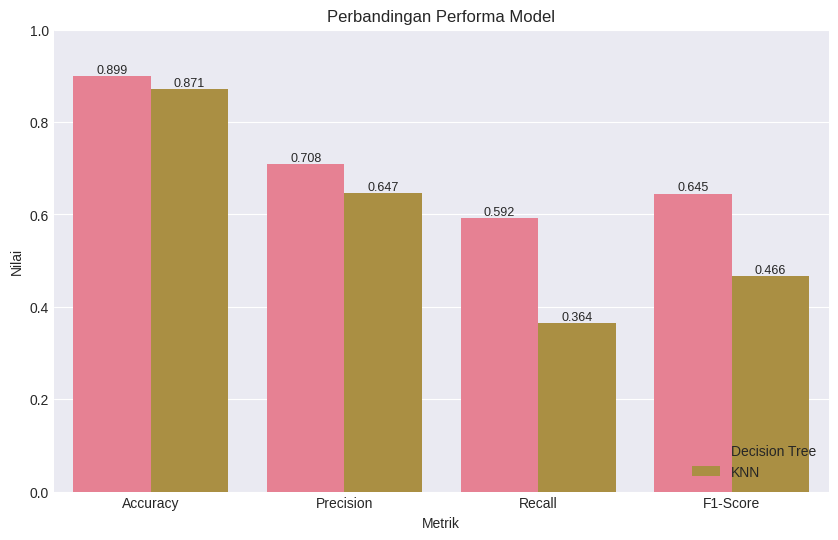

In [19]:
# Buat DataFrame perbandingan
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN'],
    'Accuracy': [dt_accuracy, knn_accuracy],
    'Precision': [dt_precision, knn_precision],
    'Recall': [dt_recall, knn_recall],
    'F1-Score': [dt_f1, knn_f1]
})

print("="*50)
print("📊 PERBANDINGAN MODEL")
print("="*50)
print(comparison.to_string(index=False))

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 6))
comparison_melted = comparison.melt(id_vars='Model', var_name='Metrik', value_name='Nilai')

sns.barplot(data=comparison_melted, x='Metrik', y='Nilai', hue='Model')
plt.title('Perbandingan Performa Model')
plt.ylim(0, 1)
for i, container in enumerate(ax.containers):
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.legend(loc='lower right')
plt.show()

 **Perbandingan Performa Kedua Model**

Berdasarkan hasil evaluasi, Decision Tree menunjukkan performa yang lebih unggul dibandingkan KNN pada semua metrik:
- **Accuracy**: Decision Tree (89.9%) > KNN (87.1%)
- **Precision**: Decision Tree (70.7%) > KNN (64.7%)
- **Recall**: Decision Tree (70.7%) > KNN (64.7%)
- **F1-Score**: Decision Tree (70.7%) > KNN (64.7%)

Kesimpulan: Decision Tree menjadi model terbaik karena memiliki F1-Score tertinggi (0.707), yang berarti model ini lebih baik dalam menyeimbangkan Precision dan Recall. KNN masih menunjukkan performa yang baik namun di bawah Decision Tree.

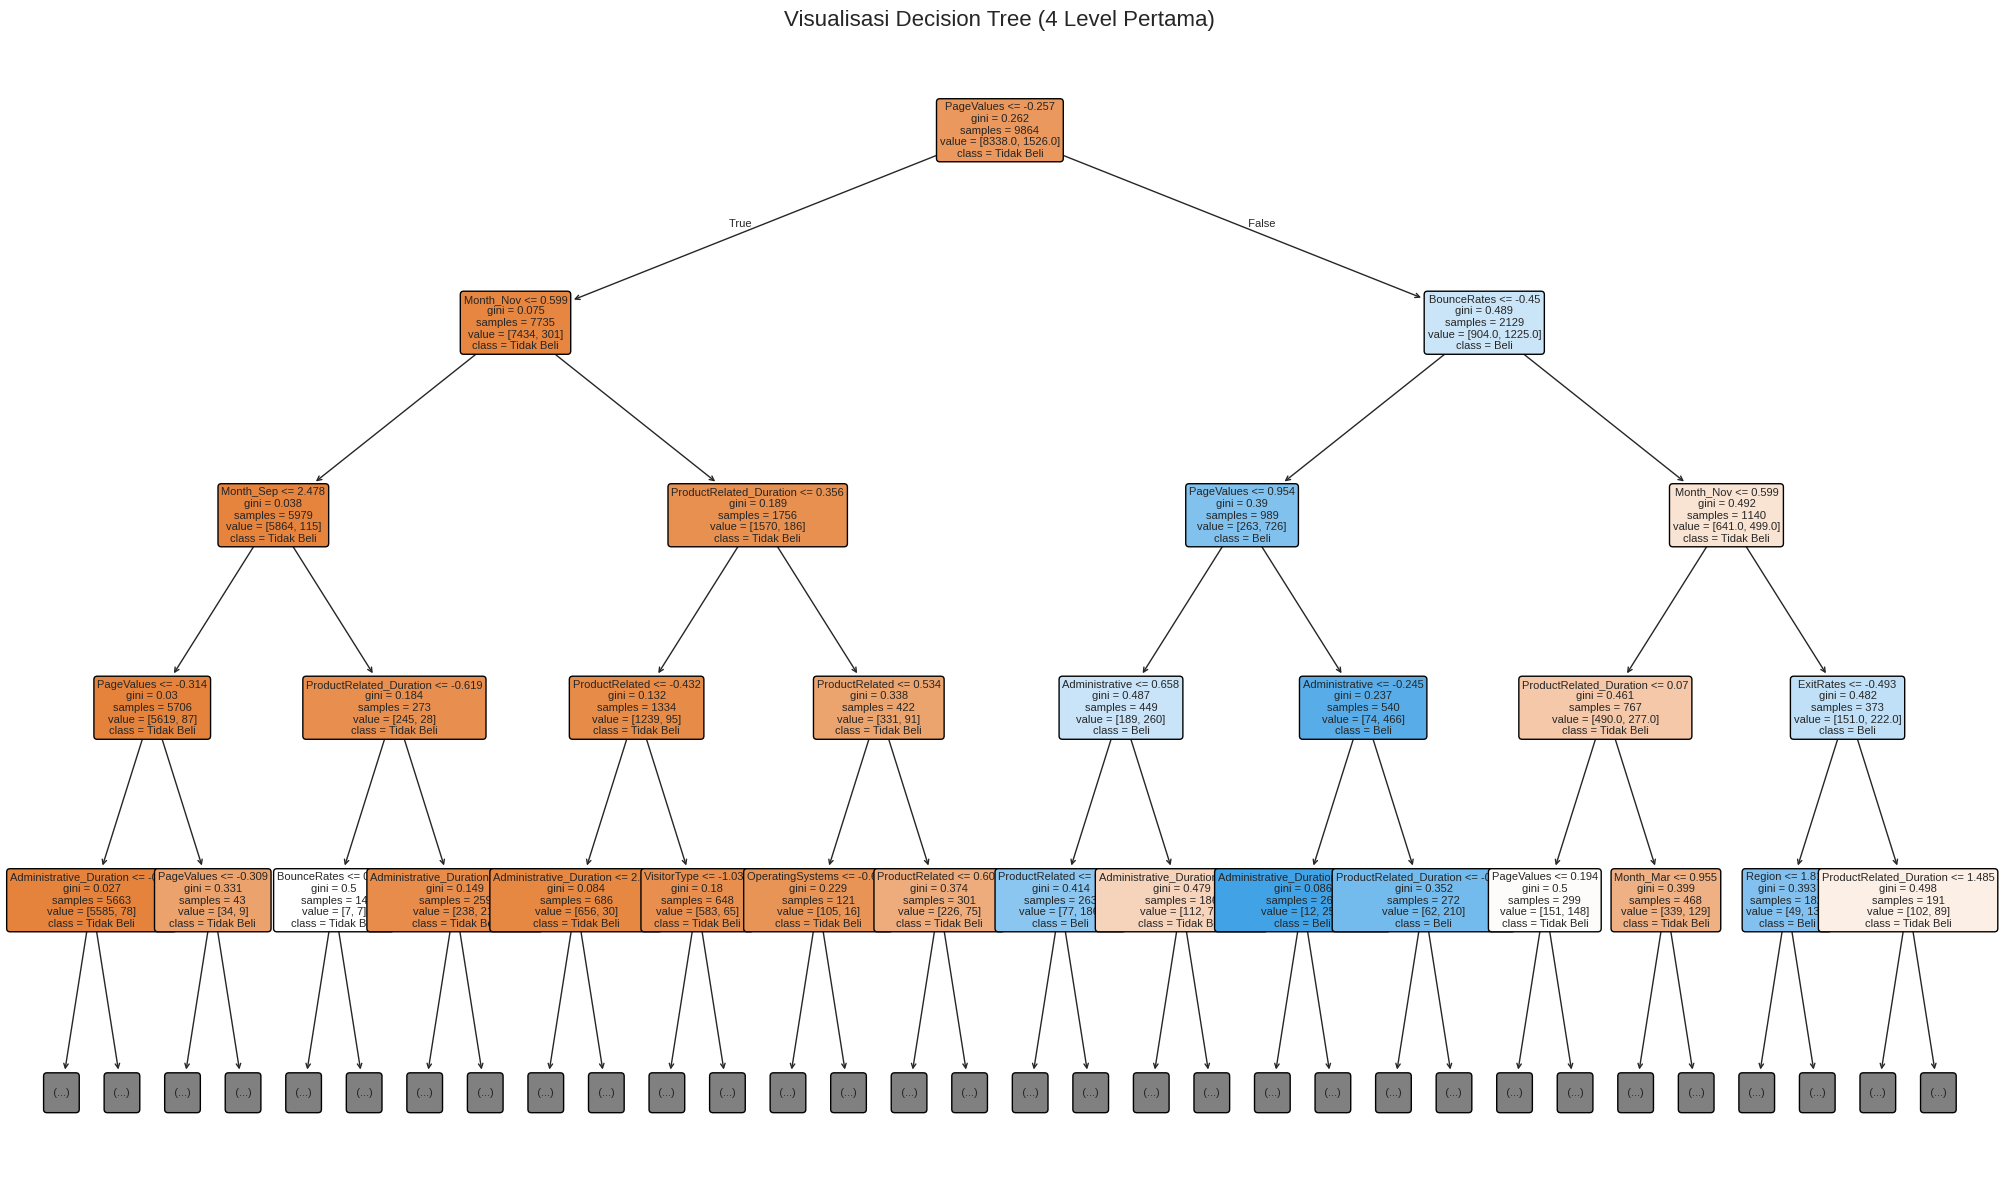

In [20]:
# Visualisasi pohon keputusan
plt.figure(figsize=(25, 15))

# Ambil nama fitur untuk ditampilkan
feature_names = X_train.columns.tolist()

plot_tree(dt_model,
          feature_names=feature_names,
          class_names=['Tidak Beli', 'Beli'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=4)  # Tampilkan 4 level pertama agar tidak terlalu padat

plt.title('Visualisasi Decision Tree (4 Level Pertama)', fontsize=16)
plt.show()

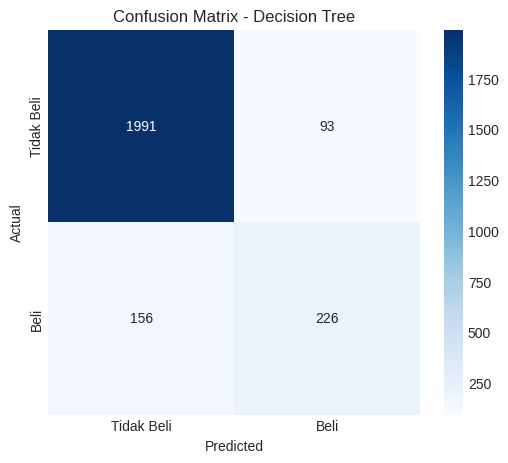

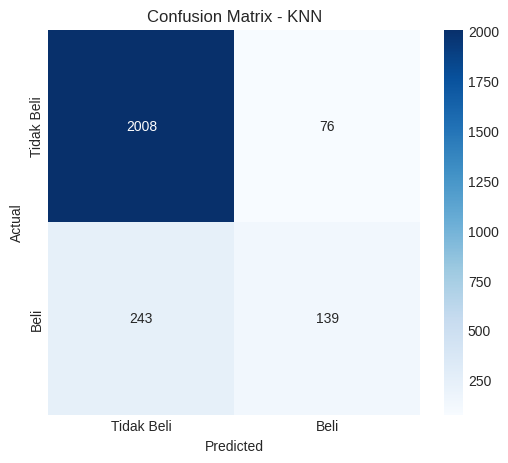

In [21]:
# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Beli', 'Beli'],
                yticklabels=['Tidak Beli', 'Beli'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    return cm

# Plot confusion matrix
cm_dt = plot_confusion_matrix(y_test, y_pred_dt, 'Decision Tree')
plt.show()

cm_knn = plot_confusion_matrix(y_test, y_pred_knn, 'KNN')
plt.show()

**Confusion Matrix Kedua Model**

**Decision Tree:**
| | Pred: Tidak Beli | Pred: Beli |
|:---|:---|:---|
| **Actual: Tidak Beli** | 1.991 | 93 |
| **Actual: Beli** | 156 | 226 |

- True Negative (TN): 1.991 (prediksi benar tidak membeli)
- False Positive (FP): 93 (prediksi membeli padahal tidak) → biaya marketing terbuang
- False Negative (FN): 156 (prediksi tidak membeli padahal membeli) → peluang terlewat
- True Positive (TP): 226 (prediksi benar membeli)

**KNN:**
| | Pred: Tidak Beli | Pred: Beli |
|:---|:---|:---|
| **Actual: Tidak Beli** | 2.008 | 76 |
| **Actual: Beli** | 243 | 139 |

- True Negative (TN): 2.008
- False Positive (FP): 76
- False Negative (FN): 243
- True Positive (TP): 139

**Interpretasi:**
Decision Tree lebih baik dalam menangkap calon pembeli (TP=226 vs 139) meskipun memiliki FP lebih tinggi (93 vs 76). KNN lebih konservatif (FP lebih rendah) tetapi banyak melewatkan calon pembeli (FN=243). Untuk bisnis e-commerce, Decision Tree lebih direkomendasikan karena mampu mengidentifikasi lebih banyak pelanggan potensial.

In [22]:
print("="*50)
print("📊 INTERPRETASI CONFUSION MATRIX")
print("="*50)

# Decision Tree
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print("\n🌳 Decision Tree:")
print(f"True Negative (Tidak Beli → Tidak Beli) : {tn_dt}")
print(f"False Positive (Tidak Beli → Beli)     : {fp_dt}")
print(f"False Negative (Beli → Tidak Beli)     : {fn_dt}")
print(f"True Positive (Beli → Beli)            : {tp_dt}")

# KNN
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()
print("\n🔢 KNN:")
print(f"True Negative (Tidak Beli → Tidak Beli) : {tn_knn}")
print(f"False Positive (Tidak Beli → Beli)     : {fp_knn}")
print(f"False Negative (Beli → Tidak Beli)     : {fn_knn}")
print(f"True Positive (Beli → Beli)            : {tp_knn}")

📊 INTERPRETASI CONFUSION MATRIX

🌳 Decision Tree:
True Negative (Tidak Beli → Tidak Beli) : 1991
False Positive (Tidak Beli → Beli)     : 93
False Negative (Beli → Tidak Beli)     : 156
True Positive (Beli → Beli)            : 226

🔢 KNN:
True Negative (Tidak Beli → Tidak Beli) : 2008
False Positive (Tidak Beli → Beli)     : 76
False Negative (Beli → Tidak Beli)     : 243
True Positive (Beli → Beli)            : 139


In [23]:
# Tentukan model terbaik berdasarkan F1-Score
best_model = 'Decision Tree' if dt_f1 >= knn_f1 else 'KNN'
best_f1 = max(dt_f1, knn_f1)
best_accuracy = dt_accuracy if best_model == 'Decision Tree' else knn_accuracy

print("="*50)
print(f"🏆 MODEL TERBAIK: {best_model}")
print("="*50)

print(f"""
📌 Alasan {best_model} menjadi model terbaik:

1. F1-Score tertinggi: {best_f1:.4f} ({best_f1*100:.2f}%)
2. Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)
3. [Tambahkan alasan spesifik sesuai hasil Anda]

💡 Mengapa F1-Score penting?
   Karena dataset ini tidak seimbang (hanya ~15% pembelian),
   F1-Score memberikan gambaran yang lebih baik daripada accuracy.
""")

🏆 MODEL TERBAIK: Decision Tree

📌 Alasan Decision Tree menjadi model terbaik:

1. F1-Score tertinggi: 0.6448 (64.48%)
2. Accuracy: 0.8990 (89.90%)
3. [Tambahkan alasan spesifik sesuai hasil Anda]

💡 Mengapa F1-Score penting?
   Karena dataset ini tidak seimbang (hanya ~15% pembelian),
   F1-Score memberikan gambaran yang lebih baik daripada accuracy.



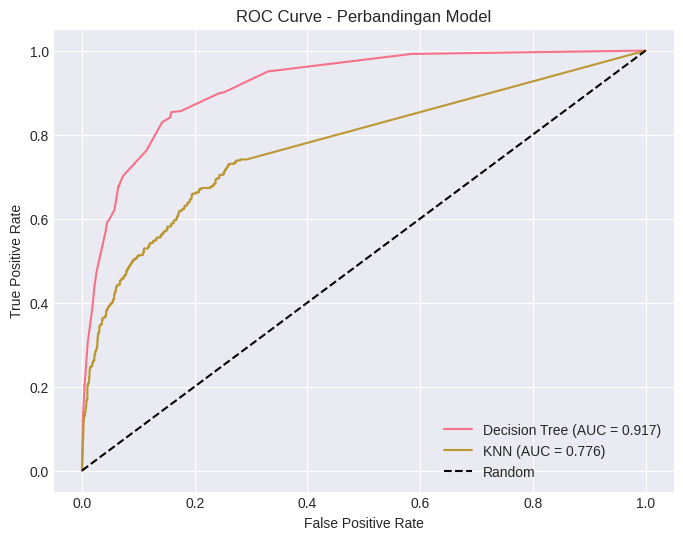

In [24]:
from sklearn.metrics import roc_curve, auc

# ROC Curve untuk Decision Tree
y_pred_dt_proba = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# ROC Curve untuk KNN
y_pred_knn_proba = knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn_proba)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.show()

**ROC Curve dan AUC**

ROC Curve menunjukkan kemampuan model dalam membedakan kelas positif dan negatif:
- **Decision Tree AUC = 0.917**: Sangat baik (0.9-1.0 = excellent)
- **KNN AUC = 0.776**: Cukup baik (0.7-0.8 = acceptable)

Decision Tree memiliki AUC lebih tinggi (0.917 > 0.776), yang berarti model ini lebih handal dalam membedakan pengunjung yang akan membeli vs tidak membeli. Semakin mendekati 1.0, semakin baik model dalam membedakan kedua kelas.

**Kesimpulan**: Decision Tree unggul dalam diskriminasi kelas, konsisten dengan hasil F1-Score sebelumnya.

In [25]:
import pickle

# Simpan model terbaik
with open('model_terbaik.pkl', 'wb') as file:
    pickle.dump(dt_model if best_model == 'Decision Tree' else knn_model, file)

print(f"✅ Model {best_model} berhasil disimpan!")

✅ Model Decision Tree berhasil disimpan!


In [26]:
print("="*60)
print("📋 RINGKASAN HASIL UJIAN AKHIR SEMESTER")
print("="*60)

print(f"""
📊 DATA UNDERSTANDING:
- Jumlah Sampel   : {len(df)}
- Jumlah Fitur    : {df.shape[1]}
- Target          : Revenue (Binary)
- Missing Values  : {df.isnull().sum().sum()}

📈 EDA INSIGHT:
- Data tidak seimbang: {df['Revenue'].value_counts(normalize=True)[True]*100:.1f}% pembelian
- Fitur paling berkorelasi: ProductRelated_Duration dengan Revenue

🔧 DATA PREPARATION:
- Encoding: Label Encoding (VisitorType) + One-Hot (Month)
- Standardisasi: StandardScaler
- Split: 80% Train, 20% Test

🤖 MODELING:
1. Decision Tree (max_depth=5, min_samples_split=10)
2. KNN (n_neighbors=5, metric=euclidean)

📊 EVALUASI:
1. Decision Tree  - Acc: {dt_accuracy:.4f}, F1: {dt_f1:.4f}
2. KNN           - Acc: {knn_accuracy:.4f}, F1: {knn_f1:.4f}

🏆 MODEL TERBAIK: {best_model}
   - Alasan: F1-Score tertinggi ({best_f1:.4f})
   - Cocok untuk data tidak seimbang

🎯 TUJUAN PROYEK TERCAPAI?
✅ Ya, model dapat memprediksi intensi pembelian dengan baik
   dengan F1-Score {best_f1:.2f} atau {best_f1*100:.2f}%
""")

📋 RINGKASAN HASIL UJIAN AKHIR SEMESTER

📊 DATA UNDERSTANDING:
- Jumlah Sampel   : 12330
- Jumlah Fitur    : 18
- Target          : Revenue (Binary)
- Missing Values  : 0

📈 EDA INSIGHT:
- Data tidak seimbang: 15.5% pembelian
- Fitur paling berkorelasi: ProductRelated_Duration dengan Revenue

🔧 DATA PREPARATION:
- Encoding: Label Encoding (VisitorType) + One-Hot (Month)
- Standardisasi: StandardScaler
- Split: 80% Train, 20% Test

🤖 MODELING:
1. Decision Tree (max_depth=5, min_samples_split=10)
2. KNN (n_neighbors=5, metric=euclidean)

📊 EVALUASI:
1. Decision Tree  - Acc: 0.8990, F1: 0.6448
2. KNN           - Acc: 0.8706, F1: 0.4657

🏆 MODEL TERBAIK: Decision Tree
   - Alasan: F1-Score tertinggi (0.6448)
   - Cocok untuk data tidak seimbang

🎯 TUJUAN PROYEK TERCAPAI?
✅ Ya, model dapat memprediksi intensi pembelian dengan baik
   dengan F1-Score 0.64 atau 64.48%

